# Multi-session pooled SARSA

This notebook demonstrates `sarsa.multisession.fit_subject`: fitting several
sessions of one subject jointly so that chosen parameters are **shared** across
sessions while others stay **session-specific**.

We:
1. simulate sessions from a known shared `(alpha, beta)` (a probabilistic
   reward-learning task),
2. fit a **pooled** model (shared `alpha`, `beta`; `gamma` fixed),
3. fit **per-session** models for comparison,
4. compare them with **BIC** and check parameter recovery.

## Generative task

A 2-state / 2-action reward-learning task. The optimal action equals the state
index; reward is stochastic (`p_hi` for the optimal action, `p_lo` otherwise),
which makes the learning rate identifiable. Actions are sampled on-policy from
`softmax(beta * Q[s])`.

In [1]:
import numpy as np
from scipy.special import softmax

from sarsa import sarsa
from sarsa import multisession as ms


def simulate_session(rng, params, q0, n_trials, p_hi=0.8, p_lo=0.2,
                     n_states=2, n_actions=2):
    """On-policy SARSA rollout in a probabilistic reward-learning task."""
    alpha, beta, gamma = params
    q = q0.copy()
    s = np.array([rng.integers(n_states)], dtype=int)
    a = int(rng.choice(n_actions, p=softmax(beta * q[tuple(s)])))
    quints = []
    for _ in range(n_trials):
        p = p_hi if a == int(s[0]) else p_lo
        r = 1.0 if rng.random() < p else 0.0
        s2 = np.array([rng.integers(n_states)], dtype=int)
        a2 = int(rng.choice(n_actions, p=softmax(beta * q[tuple(s2)])))
        quints.append(sarsa.Quintuple(s1=s, a1=a, r2=r, s2=s2, a2=a2))
        q[tuple(s) + (a,)] += alpha * (r + gamma * q[tuple(s2) + (a2,)]
                                       - q[tuple(s) + (a,)])
        s, a = s2, a2
    return quints

In [2]:
rng = np.random.default_rng(0)

ALPHA_TRUE, BETA_TRUE, GAMMA_TRUE = 0.35, 3.0, 0.0
N_SESSIONS, N_TRIALS = 6, 400
q0 = np.zeros((2, 2))  # (n_states, n_actions)

sessions = [
    simulate_session(rng, (ALPHA_TRUE, BETA_TRUE, GAMMA_TRUE), q0, N_TRIALS)
    for _ in range(N_SESSIONS)
]
print(f'{len(sessions)} sessions x {N_TRIALS} trials '
      f'= {sum(len(s) for s in sessions)} total trials')

6 sessions x 400 trials = 2400 total trials


## Pooled fit

`share_mask=[True, True, True]` shares all three canonical parameters; `gamma`
is fixed at 0 via `static_params` (this task has no temporal structure), and
`fit_beta=True` lets `beta` be estimated.

In [3]:
import warnings
warnings.simplefilter('ignore')  # silence boundary diagnostics for the demo

pooled = ms.fit_subject(
    sessions,
    q0=q0,
    p0=np.array([0.2, 1.5, 0.0]),
    share_mask=[True, True, True],
    static_params=[None, None, 0.0],  # gamma fixed
    fit_beta=True,
)

alpha_hat, beta_hat, _ = pooled.session_params[0]
print('Parameter recovery (shared across all sessions):')
print(f'  alpha: true={ALPHA_TRUE:.3f}  est={alpha_hat:.3f}')
print(f'  beta : true={BETA_TRUE:.3f}  est={beta_hat:.3f}')
print(f'  pooled loss (mean CE): {pooled.loss:.4f}')

Parameter recovery (shared across all sessions):
  alpha: true=0.350  est=0.328
  beta : true=3.000  est=2.892
  pooled loss (mean CE): 0.4106


## Pooled vs per-session (BIC)

Both models are scored on the same pooled dataset of `N` trials. The
per-session model nests the pooled one, so its in-sample NLL is always lower;
BIC's `k * ln(N)` penalty is what favors the simpler, true generating model.

In [4]:
n_total = sum(len(s) for s in sessions)

def bic(total_nll, k):
    return k * np.log(n_total) + 2 * total_nll

# Pooled: 2 free params (alpha, beta).
pooled_nll = pooled.loss * n_total
pooled_bic = bic(pooled_nll, k=2)

# Per-session: 2 free params each.
per_session_params, per_session_nll = [], 0.0
for session in sessions:
    params, loss, _, _ = sarsa.fit(
        session, q0=q0, p0=np.array([0.2, 1.5, 0.0]),
        static_params=[None, None, 0.0], fit_beta=True,
    )
    per_session_params.append(params)
    per_session_nll += loss * len(session)
per_session_bic = bic(per_session_nll, k=2 * len(sessions))

print(f'{"model":<14}{"k":>4}{"NLL":>12}{"BIC":>12}')
print(f'{"pooled":<14}{2:>4}{pooled_nll:>12.2f}{pooled_bic:>12.2f}')
print(f'{"per-session":<14}{2*len(sessions):>4}{per_session_nll:>12.2f}{per_session_bic:>12.2f}')
print()
print('pooled preferred' if pooled_bic < per_session_bic else 'per-session preferred')

model            k         NLL         BIC
pooled           2      985.33     1986.22
per-session     12      968.84     2031.07

pooled preferred


## Per-session estimates vs shared truth

Per-session MLEs scatter around the true value due to sampling noise; the
pooled estimate (dashed) is a single, tighter estimate.

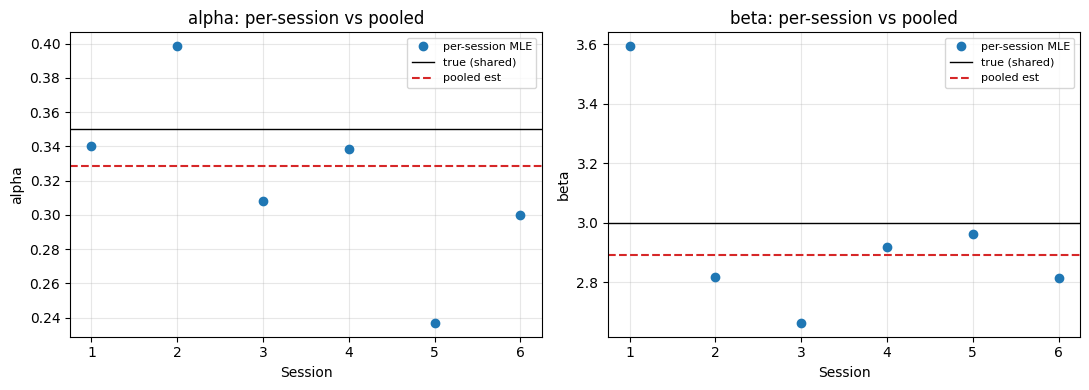

In [5]:
%matplotlib inline
import matplotlib.pyplot as plt

ps = np.array(per_session_params)
x = np.arange(1, len(sessions) + 1)

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for ax, idx, name, truth, pooled_val in [
    (axes[0], 0, 'alpha', ALPHA_TRUE, alpha_hat),
    (axes[1], 1, 'beta',  BETA_TRUE,  beta_hat),
]:
    ax.plot(x, ps[:, idx], 'o', label='per-session MLE')
    ax.axhline(truth, color='k', lw=1, label='true (shared)')
    ax.axhline(pooled_val, color='tab:red', ls='--', lw=1.5, label='pooled est')
    ax.set_xlabel('Session')
    ax.set_ylabel(name)
    ax.set_title(f'{name}: per-session vs pooled')
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)
fig.tight_layout()
plt.show()

## Partial sharing

Set `share_mask=[True, False, True]` to share `alpha` and `gamma` but let
`beta` vary per session — useful when engagement/temperature differs by day
while the learning rule is stable.

In [6]:
partial = ms.fit_subject(
    sessions,
    q0=q0,
    p0=np.array([0.2, 1.5, 0.0]),
    share_mask=[True, False, True],  # beta session-specific
    static_params=[None, None, 0.0],
    fit_beta=True,
)
print('shared params (alpha, gamma):', np.round(partial.shared_params, 3))
print('per-session beta:',
      np.round([p[sarsa.ParamIndex.beta] for p in partial.session_params], 3))

shared params (alpha, gamma): [0.328 0.   ]
per-session beta: [3.602 2.833 2.592 2.874 2.839 2.843]
